In [51]:
import torch
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
from functools import partial
import random
import numpy as np
import os
from utility import batch_to_cuda, get_idle_gpu, get_idle_port, set_randomness,  plot_with_projection, plot_mask_with_points_and_bbox, prompt_debug, setup_device_and_distributed, setup_optimizer_and_scheduler, worker_init_fn

def set_up_dataset(worker_args):
    dataset_dir = worker_args.data_dir
    train_bs = worker_args.train_bs 
    val_bs = 8
    gradient_accumulation_steps = worker_args.gradient_accumulation_steps
    
    
    train_dataset = ClimateDataset(
        data_dir=dataset_dir, train_flag=True, shot_num=worker_args.shot_num,
        augmented=worker_args.augmented, generate_prompt=True
    )
    val_dataset = ClimateDataset(data_dir=dataset_dir, train_flag=False, augmented=False, generate_prompt=True,)
    train_collate_fn = train_dataset.collate_fn
    val_collate_fn = val_dataset.collate_fn
    # Debugging mode - use smaller dataset and fewer epochs
    if hasattr(worker_args, 'debugging') and worker_args.debugging:
        debug_size = getattr(worker_args, 'debug_size', 10)  # Default to 50 samples
        indices = list(range(min(debug_size, len(train_dataset))))
        train_dataset = torch.utils.data.Subset(train_dataset, indices)
        print(f"Debug mode: Using only {len(train_dataset)} training samples")

        debug_val_size = getattr(worker_args, 'debug_val_size', 5)  # Default to 10 samples
        val_indices = list(range(min(debug_val_size, len(val_dataset))))
        val_dataset = torch.utils.data.Subset(val_dataset, val_indices)
        print(f"Debug mode: Using only {len(val_dataset)} validation samples")
        
        max_epoch_num = 2
        worker_args.valid_per_epochs = 1
        print(f"Debug mode: Setting max_epoch_num to {max_epoch_num} and valid_per_epochs to {worker_args.valid_per_epochs}")
        
    # Adjust batch size for gradient accumulation
    actual_train_bs = train_bs // gradient_accumulation_steps
    if actual_train_bs < 1:
        actual_train_bs = 1
        print(f"Warning: gradient_accumulation_steps ({gradient_accumulation_steps}) is larger than train_bs ({train_bs}). Setting actual batch size to 1.")
    
    effective_batch_size = actual_train_bs * gradient_accumulation_steps
    
    print(f"Effective batch size: {effective_batch_size} (actual_bs: {actual_train_bs}, accumulation: {gradient_accumulation_steps})")
        
    train_workers, val_workers = 4, 8
    
    sampler = None
        
    train_dataloader = DataLoader(
        dataset=train_dataset, batch_size=actual_train_bs, shuffle=sampler is None, num_workers=train_workers,
        sampler=sampler, drop_last=False, collate_fn=train_collate_fn,
        worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )
    val_dataloader = DataLoader(
        dataset=val_dataset, batch_size=val_bs, shuffle=False, num_workers=val_workers,
        drop_last=False, collate_fn=val_collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )
    
    return train_dataloader, val_dataloader

In [52]:
from dataset.climatenet import ClimateDataset
from model.prompt_generator import PromptGenerator
from model.prompt.prompt_maker import PromptMaker
from climatesam import ClimateSAM

def set_up_model(worker_args, device):
    climatesam = ClimateSAM(
        model_type=worker_args.sam_type, 
        mlp_ratio=worker_args.image_encoder_mlp_ratio,
        enable_wandb_logging=getattr(worker_args, 'debugging', False)  # Only log if debugging=True
    ).to(device)
    
    # Load pretrained weights
    if worker_args.load_pretrained:
        if worker_args.phase == 1:
            image_encoder_path = os.path.join(worker_args.exp_dir,'best_weights', f"phase_2_weights_best.pth")
            phase_1_checkpoint = torch.load(image_encoder_path, map_location=device)
            print(f"Pretrained weights from phase 1 loaded from {image_encoder_path}")
            climatesam.image_encoder.load_state_dict(phase_1_checkpoint['image_encoder'])
            print(f"Image encoder weights loaded from {image_encoder_path}")
            climatesam.mask_decoder.load_state_dict(phase_1_checkpoint['mask_decoder'])
            print(f"Mask decoder weights loaded from {image_encoder_path}")
    
    
    ###################################################
    num_features_map = {
        'vit_b': 12,
        'vit_l': 24,
        'vit_h': 32
    }
    features_per_block = {
        'vit_b': 3,
        'vit_l': 6,
        'vit_h': 9
    }
    
    in_channels = {
        'vit_b': 768,
        'vit_l': 1024,
        'vit_h': 1280
    }
    
    prompt_generator = PromptGenerator(
        in_channels=in_channels[worker_args.sam_type],
        fused_channels=1,
        num_features=num_features_map[worker_args.sam_type],
        features_per_block=features_per_block[worker_args.sam_type]
    ).to(device)
    
    for params in climatesam.image_encoder.parameters():
        params.requires_grad = False
    for params in climatesam.mask_decoder.parameters():
        params.requires_grad = False
        

    return climatesam, prompt_generator

In [53]:
from parser_config import parse
import sys
original_argv = sys.argv
sys.argv = ['train_complete_test.ipynb', '--config', 'input_config_test']
worker_args = parse()
max_epoch_num = worker_args.max_epoch_num 
train_dataloader, val_dataloader = set_up_dataset(worker_args)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# climatesam, prompt_generator = set_up_model(worker_args, device)


Debug mode: Using only 10 training samples
Debug mode: Using only 5 validation samples
Debug mode: Setting max_epoch_num to 2 and valid_per_epochs to 1
Effective batch size: 2 (actual_bs: 2, accumulation: 1)


In [54]:
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def show_mask_like_gt(gt_mask, index=0, figsize=(8, 6), title=None):
    """
    Display a gt_mask-like object (list/tuple of tensors or a single tensor/ndarray).

    Args:
      gt_mask: list/tuple of masks or a single mask tensor/ndarray
      index: which item in the batch to show (if gt_mask is a list/tuple)
      figsize: figure size
      title: optional title
    Returns:
      matplotlib.figure.Figure
    """
    # select item from batch-like container
    mask = gt_mask[index] if isinstance(gt_mask, (list, tuple)) else gt_mask

    # convert torch tensor to numpy if needed
    if hasattr(mask, "cpu"):
        mask = mask.cpu().numpy()

    mask = np.squeeze(mask)

    cmap_local = ListedColormap(['black', 'blue', 'red'])  # 0=background, 1=TC, 2=AR
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mask, cmap=cmap_local, vmin=0, vmax=2)
    ax.set_title(title or f"gt_mask[{index}]")
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
    cbar.set_label("label")
    ax.axis("off")
    # plt.show()
    return fig

In [55]:
for batch in val_dataloader:
    batch = batch_to_cuda(batch, device)
    break

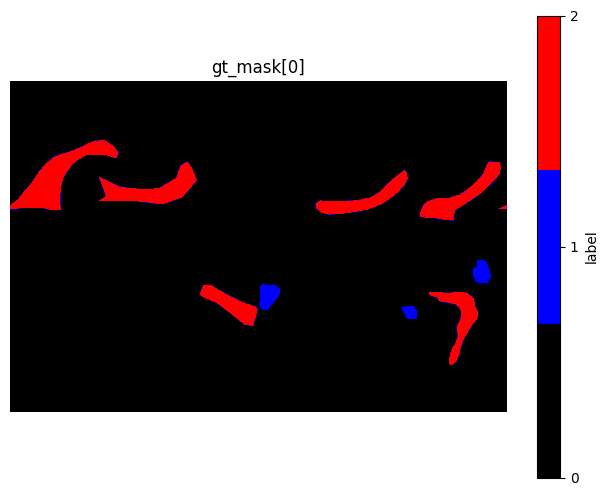

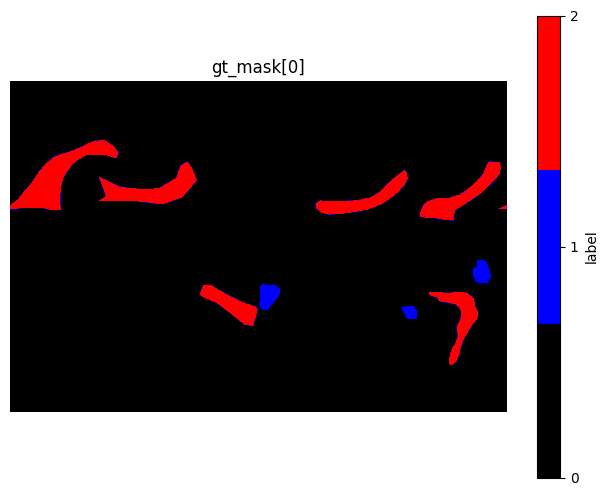

In [56]:
show_mask_like_gt(batch['gt_mask'][0])

In [70]:
prompt_maker = PromptMaker(prompt_type='point', positive_point_num=2, negative_point_num=2)
prompt_dict = prompt_maker.make_prompts(batch['gt_mask'], prompt_type='point')

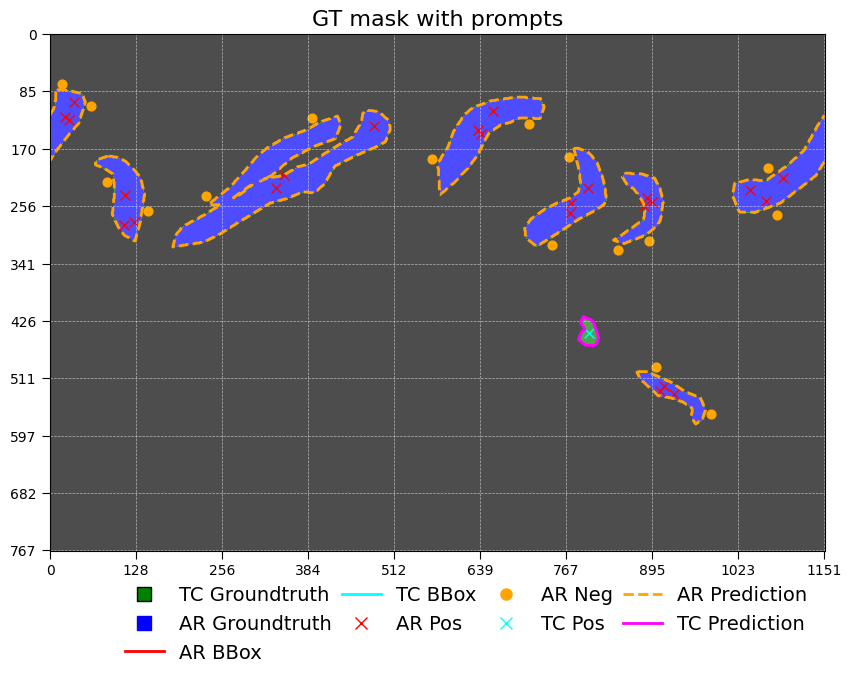

In [74]:
import csv
import os


# Save visualization to a specific path (empty string would make save fail)
save_path = 'exp/gt_prompts.png'
os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)

i=4
fig = plot_mask_with_points_and_bbox(
    mask=batch['gt_mask'][i],
    ar_points=prompt_dict.get('ar_point_prompts')[i],
    tc_points=prompt_dict.get('tc_point_prompts')[i],
    ar_bbox=prompt_dict.get('ar_bbox_prompts')[i],
    tc_bbox=prompt_dict.get('tc_bbox_prompts')[i],
    tc_pred_mask= batch['gt_mask'][i] ==1,
    ar_pred_mask= batch['gt_mask'][i] ==2,
    save_path=save_path,
    title='GT mask with prompts',
    axis=True,
)

fig



In [18]:
# Example: construct illustrative point prompts, bbox prompts and mask predictions for the first sample
import cv2
import numpy as np
import torch

# pick first sample mask from the already-loaded batch
mask_tensor = batch['gt_mask'][0]
if hasattr(mask_tensor, 'cpu'):
    mask_np = mask_tensor.cpu().numpy()
else:
    mask_np = np.asarray(mask_tensor)

h, w = mask_np.shape
# binary masks for AR (value==2) and TC (value==1)
ar_mask = (mask_np == 2).astype(np.uint8)
tc_mask = (mask_np == 1).astype(np.uint8)

# helper to compute centroid or fallback point
def centroid_or_fallback(bin_mask, fallback):
    ys, xs = np.where(bin_mask)
    if len(xs) == 0:
        return fallback
    return (int(xs.mean()), int(ys.mean()))

ar_cent = centroid_or_fallback(ar_mask, (w // 4, h // 4))
tc_cent = centroid_or_fallback(tc_mask, (3 * w // 4, 3 * h // 4))

# build point prompts as a list with a single-element per-sample tensor
# shape: [ [ [x, y] ] ] -> (1,1,2) to match expected shapes
ar_points = [torch.tensor([[[float(ar_cent[0]), float(ar_cent[1])]]], dtype=torch.float32)]
tc_points = [torch.tensor([[[float(tc_cent[0]), float(tc_cent[1])]]], dtype=torch.float32)]

# bounding box helper (center + size)
def make_bbox(cx, cy, size=120):
    x1 = max(0, cx - size // 2)
    y1 = max(0, cy - size // 2)
    x2 = min(w - 1, cx + size // 2)
    y2 = min(h - 1, cy + size // 2)
    return [float(x1), float(y1), float(x2), float(y2)]

ar_bbox = [torch.tensor([[[*make_bbox(*ar_cent, size=160)]]], dtype=torch.float32)]
tc_bbox = [torch.tensor([[[*make_bbox(*tc_cent, size=160)]]], dtype=torch.float32)]

# create simple predicted masks by dilating the GT binary masks so they look like imperfect predictions
kernel = np.ones((15, 15), np.uint8)
ar_pred = cv2.dilate(ar_mask, kernel, iterations=1).astype(np.float32)
tc_pred = cv2.dilate(tc_mask, kernel, iterations=1).astype(np.float32)

# convert preds to torch tensors (plot function accepts torch or numpy)
ar_pred_t = torch.from_numpy(ar_pred)
tc_pred_t = torch.from_numpy(tc_pred)

save_path = 'exp/example_prompts.png'
fig = plot_mask_with_points_and_bbox(
    mask=mask_np,
    ar_points=ar_points,
    tc_points=tc_points,
    ar_bbox=ar_bbox,
    tc_bbox=tc_bbox,
    tc_pred_mask=tc_pred_t,
    ar_pred_mask=ar_pred_t,
    radius=8,
    save_path=save_path,
    axis=True,
    title=None
)
print(f"Saved example visualization to: {save_path}")
# Also print the prompts saved to CSV (same base name)
print(f"Prompts CSV: {os.path.splitext(save_path)[0] + '.csv'}")

Saved example visualization to: exp/example_prompts.png
Prompts CSV: exp/example_prompts.csv


In [19]:
# World projection: show RGB with AR/TC GT contours and labels (no prompts)
import os
import cv2
import numpy as np
import torch
from PIL import Image

# take first sample
image_tensor = batch['input'][0]
mask_tensor = batch['gt_mask'][0]

# convert image to HWC numpy and normalize for visualization
image_np = image_tensor.cpu().numpy() if torch.is_tensor(image_tensor) else np.asarray(image_tensor)
if image_np.ndim == 3 and image_np.shape[0] == 3:
    image_vis = np.squeeze(image_np).transpose(1, 2, 0)
else:
    image_vis = image_np
minv, maxv = image_vis.min(), image_vis.max()
if maxv > minv:
    image_vis = (image_vis - minv) / (maxv - minv)

# prepare GT masks and resize to projection size expected by plot_with_projection
target_w, target_h = 1152, 768
mask_np = mask_tensor.cpu().numpy() if torch.is_tensor(mask_tensor) else np.asarray(mask_tensor)
mask_np = np.squeeze(mask_np)
ar_gt = (mask_np == 2).astype(np.float32)
tc_gt = (mask_np == 1).astype(np.float32)

ar_gt_resized = cv2.resize(ar_gt, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
tc_gt_resized = cv2.resize(tc_gt, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

# create mild prediction-like overlays (optional) by dilation for visualization
kernel = np.ones((15, 15), np.uint8)
ar_pred = cv2.dilate(ar_gt_resized, kernel, iterations=1).astype(np.float32)
tc_pred = cv2.dilate(tc_gt_resized, kernel, iterations=1).astype(np.float32)

# save and display using existing utility
save_path = 'exp/world_projection.png'
plot_array, title = plot_with_projection(
    image=image_vis,
    ar_pred=None,      # set to None to avoid showing predictions, only GT
    tc_pred=None,
    ar_gt=ar_gt_resized,
    tc_gt=tc_gt_resized,
    save_path=save_path,
    use_projection=True,
    epoch=0,
    title='World projection with GT masks (no prompts)'
)

# display result inline
img = Image.fromarray(plot_array)
display(img)
print(f"Saved world projection to: {save_path}")

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:3845: error: (-215:Assertion failed) !dsize.empty() in function 'cv::hal::resize'


In [ ]:
# Debugging: inspect image array before calling plot_with_projection and fix shape/dtype
import os
import cv2
import numpy as np
import torch
from PIL import Image

image_tensor = batch['input'][0]
mask_tensor = batch['gt_mask'][0]

# Convert to numpy
image_np = image_tensor.cpu().numpy() if torch.is_tensor(image_tensor) else np.asarray(image_tensor)
print('raw image_np.shape, dtype, min/max:', getattr(image_np, 'shape', None), getattr(image_np, 'dtype', None), np.nanmin(image_np), np.nanmax(image_np))

# Handle channel-first C,H,W -> H,W,C
if image_np.ndim == 3 and image_np.shape[0] == 3:
    image_vis = np.squeeze(image_np).transpose(1, 2, 0)
    print('Converted from C,H,W to H,W,C ->', image_vis.shape)
elif image_np.ndim == 3 and image_np.shape[2] == 3:
    image_vis = image_np
    print('Image already H,W,C ->', image_vis.shape)
elif image_np.ndim == 2:
    # single channel -> make 3-channel gray
    image_vis = np.stack([image_np]*3, axis=-1)
    print('Converted single-channel to H,W,3 ->', image_vis.shape)
else:
    # unexpected shape
    raise RuntimeError(f'Unexpected image shape: {image_np.shape}')

# Normalize to 0-1 float32
minv, maxv = image_vis.min(), image_vis.max()
if maxv > minv:
    image_vis = (image_vis - minv) / (maxv - minv)
image_vis = image_vis.astype(np.float32)
print('post-normalize shape/dtype/min/max:', image_vis.shape, image_vis.dtype, image_vis.min(), image_vis.max())

# Ensure contiguous memory for cv2
image_vis = np.ascontiguousarray(image_vis)

# Prepare GT masks resized to projection dims
target_w, target_h = 1152, 768
mask_np = mask_tensor.cpu().numpy() if torch.is_tensor(mask_tensor) else np.asarray(mask_tensor)
mask_np = np.squeeze(mask_np)
ar_gt = (mask_np == 2).astype(np.float32)
tc_gt = (mask_np == 1).astype(np.float32)

ar_gt_resized = cv2.resize(ar_gt, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
tc_gt_resized = cv2.resize(tc_gt, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

save_path = 'exp/world_projection_fixed.png'
try:
    plot_array, title = plot_with_projection(
        image=image_vis,
        ar_pred=None,
        tc_pred=None,
        ar_gt=ar_gt_resized,
        tc_gt=tc_gt_resized,
        save_path=save_path,
        use_projection=True,
        epoch=0,
        title='World projection (fixed image)'
    )
    img = Image.fromarray(plot_array)
    display(img)
    print(f'Saved fixed world projection to: {save_path}')
except Exception as e:
    print('plot_with_projection raised exception:', type(e), e)
    # try a fallback: resize image to target and call plot_with_projection with that image
    try:
        resized_img = cv2.resize(image_vis, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
        plot_array, title = plot_with_projection(
            image=resized_img,
            ar_pred=None,
            tc_pred=None,
            ar_gt=ar_gt_resized,
            tc_gt=tc_gt_resized,
            save_path=save_path,
            use_projection=True,
            epoch=0,
            title='World projection (fallback resized)'
        )
        img = Image.fromarray(plot_array)
        display(img)
        print('Saved fallback projection to:', save_path)
    except Exception as e2:
        print('Fallback also failed:', type(e2), e2)

raw image_np.shape, dtype, min/max: (16, 768, 1152) float32 0.0 254.0


RuntimeError: Unexpected image shape: (16, 768, 1152)

: 

In [9]:
from model.prompt.prompt_maker import make_point_prompts

a = make_point_prompts((batch['gt_mask'][0].cpu().numpy()  == 1).astype(np.uint8), connectivity=8, num_positive_points=1, num_negative_points=1)

In [172]:
a[0]

(tensor([[[1082.0000,  451.0000],
          [1093.3575,  443.4448],
          [1072.0000,  414.0000]],
 
         [[ 601.0000,  496.0000],
          [ 598.3083,  497.8030],
          [ 637.0000,  501.0000]],
 
         [[ 935.0000,  547.0000],
          [ 926.9736,  535.7643],
          [ 919.0000,  561.0000]]]),
 tensor([[1., 1., 0.],
         [1., 1., 0.],
         [1., 1., 0.]]))

In [6]:
total_loss

tensor(2.0359, device='cuda:0', grad_fn=<AddBackward0>)

In [10]:
prompt_dict

{'ar_point_prompts': [None, None],
 'tc_point_prompts': [None, None],
 'ar_bbox_prompts': [None, None],
 'tc_bbox_prompts': [None, None],
 'ar_mask_prompts': [None, None],
 'tc_mask_prompts': [None, None],
 'ar_object_masks': [None, None],
 'tc_object_masks': [None, None]}

In [ ]:
# Example: construct illustrative point prompts, bbox prompts and mask predictions for the first sample
import cv2
import numpy as np
import torch
import os

# pick first sample mask from the already-loaded batch
mask_tensor = batch['gt_mask'][0]
if hasattr(mask_tensor, 'cpu'):
    mask_np = mask_tensor.cpu().numpy()
else:
    mask_np = np.asarray(mask_tensor)

h, w = mask_np.shape
# binary masks for AR (value==2) and TC (value==1)
ar_mask = (mask_np == 2).astype(np.uint8)
tc_mask = (mask_np == 1).astype(np.uint8)

# helper to compute centroid or fallback point
def centroid_or_fallback(bin_mask, fallback):
    ys, xs = np.where(bin_mask)
    if len(xs) == 0:
        return fallback
    return (int(xs.mean()), int(ys.mean()))

ar_cent = centroid_or_fallback(ar_mask, (w // 4, h // 4))
tc_cent = centroid_or_fallback(tc_mask, (3 * w // 4, 3 * h // 4))

# build point prompts as a list with a single-element per-sample tensor
# shape: [ [ [x, y] ] ] -> (1,1,2) to match expected shapes
ar_points = [torch.tensor([[[float(ar_cent[0]), float(ar_cent[1])]]], dtype=torch.float32)]
tc_points = [torch.tensor([[[float(tc_cent[0]), float(tc_cent[1])]]], dtype=torch.float32)]

# bounding box helper (center + size)
def make_bbox(cx, cy, size=120):
    x1 = max(0, cx - size // 2)
    y1 = max(0, cy - size // 2)
    x2 = min(w - 1, cx + size // 2)
    y2 = min(h - 1, cy + size // 2)
    return [float(x1), float(y1), float(x2), float(y2)]

ar_bbox = [torch.tensor([[[*make_bbox(*ar_cent, size=160)]]], dtype=torch.float32)]
tc_bbox = [torch.tensor([[[*make_bbox(*tc_cent, size=160)]]], dtype=torch.float32)]

# create simple predicted masks by dilating the GT binary masks so they look like imperfect predictions
kernel = np.ones((15, 15), np.uint8)
ar_pred = cv2.dilate(ar_mask, kernel, iterations=1).astype(np.float32)
tc_pred = cv2.dilate(tc_mask, kernel, iterations=1).astype(np.float32)

# convert preds to torch tensors (plot function accepts torch or numpy)
ar_pred_t = torch.from_numpy(ar_pred)
tc_pred_t = torch.from_numpy(tc_pred)

save_path = 'exp/example_prompts.png'
fig = plot_mask_with_points_and_bbox(
    mask=mask_np,
    ar_points=ar_points,
    tc_points=tc_points,
    ar_bbox=ar_bbox,
    tc_bbox=tc_bbox,
    tc_pred_mask=tc_pred_t,
    ar_pred_mask=ar_pred_t,
    radius=8,
    save_path=save_path,
    axis=True,
    title=None
)
print(f"Saved example visualization to: {save_path}")
# Also print the prompts saved to CSV (same base name)
print(f"Prompts CSV: {os.path.splitext(save_path)[0] + '.csv'}")